### **1. Menyiapkan Lingkungan Kerja**

In [137]:
!python --version

Python 3.10.21


### **2. Memasang Pustaka Inti**

In [145]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [146]:
# Cek versi pada library yang digunakan
print('OpenCV     :', cv2.__version__)
print('NumPy      :', np.__version__)
# print('Matplotlib :', plt.__version__)

OpenCV     : 5.0.0
NumPy      : 2.2.6


### **3. Membaca dan Menampilkan Citra**

In [173]:
img = cv2.imread('img/simpang.jpg') # Membaca citra
# Mengkonversi citra BGR menjadi RGB
img_conv_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Mengkonversi citra RGB menjadi Grayscale
img_gray = cv2.cvtColor(img_conv_rgb, cv2.COLOR_RGB2GRAY)

In [148]:
# Mengecek isi berkas pemanggilan
# if img is None:
#     print('Berkas tidak ditemukan. Periksa nama dan lokasinya.')
# else:
#     cv2.namedWindow('Citra Simpang', cv2.WINDOW_NORMAL)
#     img = cv2.imshow('Citra Simpang', img) # Tampilkan citra dalam bentuk popup window
#     cv2.waitKey(0)
#     cv2.destroyAllWindows()

Text(0.5, 1.0, 'Citra Gray')

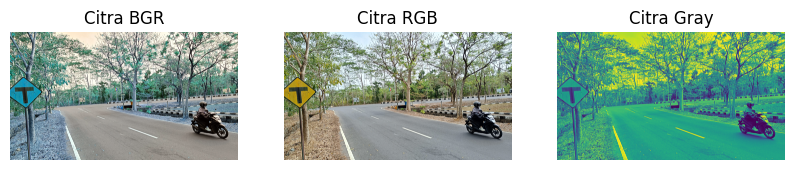

In [174]:
plt.figure(figsize=(10, 8))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.axis('off')
plt.title("Citra BGR")

plt.subplot(1, 3, 2)
plt.imshow(img_conv_rgb)
plt.axis('off')
plt.title("Citra RGB")

plt.subplot(1, 3, 3)
plt.imshow(img_gray)
plt.axis('off')
plt.title("Citra Gray")

In [175]:
# Menulis citra dari array lalu disimpan ke directory tertentu
cv2.imwrite('img/simpang_gray.jpg', img_gray)
print('Citra keabuan berhasil disimpan.')

Citra keabuan berhasil disimpan.


### **4. Menelusuri Nilai Piksel**

In [151]:
# Atribut Citra RGB
print('Bentuk citra :', img.shape)
print('Tipe data :', img.dtype)
print('Jumlah piksel :', img.size)

Bentuk citra : (2304, 4096, 3)
Tipe data : uint8
Jumlah piksel : 28311552


In [152]:
piksel = img[100, 200] # Ambil nilai piksel dari baris y=100 dan kolom x=200
print('Nilai BGR pada (100, 200) : ', piksel)
print('Biru :', piksel[0])
print('Hijau :', piksel[1])
print('Merah :', piksel[2])

Nilai BGR pada (100, 200) :  [ 94 106  88]
Biru : 94
Hijau : 106
Merah : 88


In [153]:
# Atribut Citra Grayscale
print('Bentuk citra :', img_gray.shape)
print('Tipe data :', img_gray.dtype)
print('Jumlah piksel :', img_gray.size)

Bentuk citra : (2304, 4096)
Tipe data : uint8
Jumlah piksel : 9437184


In [154]:
# Ambil nilai piksel dengan matriks 5x5 
# (Vertikal Y) ambil nilai dari rentang 100 hingga 105
# (Horizontal X) ambil nilai dari rentang 200 hingga 205
potongan = img_gray[100:105, 200:205]
print("Nilai potongan : \n",potongan)
print("Nilai min :",potongan.min()) # Ambil nilai piksel terkecil
print("Nilai max :",potongan.max()) # Ambil nilai piksel terbesar

Nilai potongan : 
 [[ 99 106 105 106 112]
 [115 122 120 106  98]
 [110 110 128 123  97]
 [141 103 123 117 118]
 [205 137 109 141 171]]
Nilai min : 97
Nilai max : 205


##### **Mengapa potongan 5×5 hanya berisi 1 angka per piksel?**
- Kode Pertama (img[100, 200]): ia mengambil piksel dari variabel img, yang mana citra tersebut berwarna BGR. Setiap piksel memiliki 3 channel warna (Biru, Hijau, Merah).
- Kode Kedua (gray[100:105, 200:205]): ia mengambil potongan dari variabel gray, yang merupakan gambar Grayscale. Gambar grayscale hanya memiliki 1 channel warna (skala keabuan dari 0-255). Itulah mengapa isi matriksnya hanya berupa angka tunggal, bukan seperti 3 nilai BGR.

### **5. Membaca Berkas Video**

In [155]:
# Membaca data video  
video = cv2.VideoCapture('vid/simpang.mp4')
# Mendapatkan rata-rata FPS video
fps = video.get(cv2.CAP_PROP_FPS)
# Mendapatkan seluruh total FPS video
jumlah = video.get(cv2.CAP_PROP_FRAME_COUNT)
print('FPS :', fps)
print('Jumlah frame :', jumlah)
print('Durasi detik :', jumlah / fps)

FPS : 30.0
Jumlah frame : 983.0
Durasi detik : 32.766666666666666


In [156]:
# Mengambil frame pertama untuk dibaca 
# Ia mengeluarkan dua output yaitu boolean dan matriks citra
berhasil, frame = video.read()
if berhasil:
    cv2.imwrite('img/frame_pertama.jpg', frame)
    print('Bingkai pertama disimpan.')
else: 
    print('Gagal membaca bingkai')

video.release() # Mengakhiri proses membaca dan menulis file

Bingkai pertama disimpan.


In [157]:
img_frame = cv2.imread('img/frame_pertama.jpg')
print('Bentuk (shape) frame :', img_frame.shape)

Bentuk (shape) frame : (720, 1280, 3)
